## SHAP variables analysis on Location Choice Model
> Dec 17th, 2025

Topic: Transportation Accessibility in Regional Forecast 
-   Insights from SEMCOG's Experiences

Guangyu Li (li@semcog.org) and Tian Xie​ (xie@semcog.org)

In [1]:
# loading modules
import numpy as np
import pandas as pd
%load_ext autoreload
%autoreload 2

### SHAP HLCM Analysis

#### Loading Training and Evaluation dataset

In [2]:
import torch
import shap
# Warning:
# forecast_estimation is a SEMCOG private library that contains utilities for model training and evaluation
from forecast_estimation.utils import (
    add_hh_indicators, # function that adds household indicators
    std_scaler_transform, # function that standardizes features
)
from sklearn.model_selection import StratifiedShuffleSplit

##### HLCM segment config

In [4]:
# configuration
la_id = 3
cat1,cat2,cat3 = "no_children", "with_seniors", "highinc"
# model path
model_path = '/mnt/D/RDF2050/estimation/models/models_25Dec8/pts/lcm_nn_la%s_%s_%s_%s_std.pt' % (la_id, cat1, cat2, cat3)

##### Loading data

In [5]:
# training data loading
hh_path = '/mnt/D/RDF2050/estimation/data/all_vars_w_access/hh_%s.csv'
b_path = '/mnt/D/RDF2050/estimation/data/all_vars_w_access/b_hlcm_full_%s.csv'
baseyear_building_path ='/mnt/D/RDF2050/estimation/data/buildings_2020.csv'
hh_filter_columns = ["building_id", "large_area_id", "mcd_model_quota", "year_built", "residential_units"]
b_filter_columns = ["large_area_id", "mcd_model_quota", "residential_units"]

# load data
hh = pd.read_csv(hh_path % la_id, index_col='household_id')
b = pd.read_csv(b_path % la_id, index_col='building_id')
b = b[b.residential_units>0]

hh = add_hh_indicators(hh)
### Experimental: spectial cities adjustment
# LA 3, cities 1025, taz 420-472
if la_id == 3:
	bbase = pd.read_csv(baseyear_building_path, index_col=0)
	# hh to sample
	hh_to_sample = hh.join(bbase[['city_id']], on='building_id')
	hh_to_sample = hh_to_sample.fillna(-1).astype(int)
	hh_to_sample = hh_to_sample[hh_to_sample.city_id==1025]
	hh_to_sample = hh_to_sample[hh_to_sample.persons>2]
	samples = hh_to_sample.sample(frac=0.03)
	# apply to hh
	hh = pd.concat([hh, samples], axis=0)
	print('Added %s hhs in Dearborn' % len(samples))

print(cat1,cat2,cat3)
hh_seg = hh[(hh[cat1]==1)&(hh[cat2]==1)&(hh[cat3]==1)]

# get training columns
train_cols = np.array([col for col in b.columns if col not in b_filter_columns])

vars_to_use = []
for col in b.columns:
	# dropping filter column and String columns and col with 0 std
	if b[col].dtype != 'object' and col not in b_filter_columns and b[col].std() > 0.0:
		vars_to_use.append(col)

# houseolds counts
hc = len(hh_seg)

negative_sample_b_idx = np.random.choice(b[~b.index.isin(hh_seg.building_id)].index.values, hc, replace=False)
sample_b_idx = np.concatenate((hh_seg.building_id.values, negative_sample_b_idx))
np.random.shuffle(sample_b_idx)

sample_b = b.loc[sample_b_idx, vars_to_use]

# std
sample_b = std_scaler_transform(sample_b)

target = sample_b.index.isin(hh_seg.building_id).astype('int8')

# train eval split
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.1, random_state=0)
train_idx = sss.split(sample_b, target)
trn_split,val_split = None, None
for split in train_idx:
	trn_split = split[0]
	val_split = split[1]

trn_df,val_df = sample_b.iloc[trn_split],sample_b.iloc[val_split]
trn_tar,val_tar = target[trn_split], target[val_split]
print('Training v. Eval sample size:', len(trn_df), len(val_df))

adding hh indicators..
Added 500 hhs in Dearborn
no_children with_seniors highinc
Training v. Eval sample size: 59691 6633


#### Loading saved NN model

In [6]:
# Warning:
# forecast_estimation is a SEMCOG private library that contains utilities for model training and evaluation
from forecast_estimation.models.LCM_torch import LCM_NN # function that defines LCM neural network model

# load model from saved state
device = torch.device('cuda')
state = torch.load(model_path, map_location=device)
model = LCM_NN( state['input_size'], hidden_layer=state['hidden_layer'], lr=state['lr'], weight_decay=state['weight_decay'])
model.load_model(model_path)

#### SHAP Visualization

Generating SHAP Beeswarm Plot:


<Axes: xlabel='SHAP value (impact on model output)'>

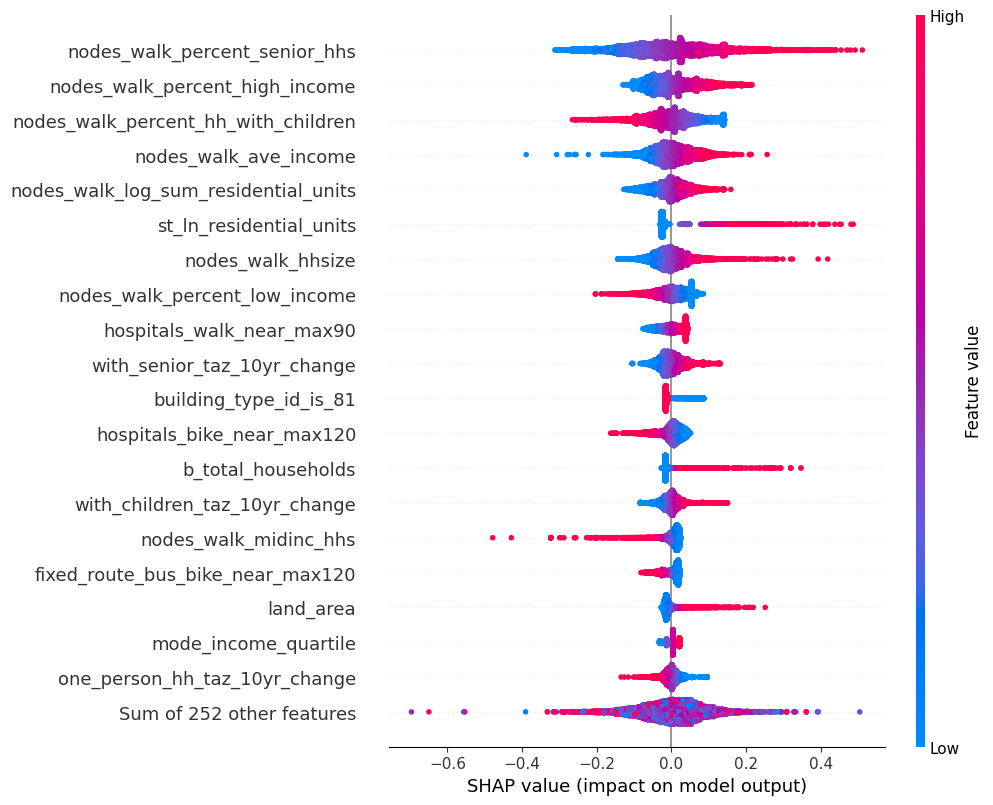

In [7]:
X_val = val_df
model.eval() # Set model to evaluation mode
X_val_tensor = torch.tensor(X_val.values, dtype=torch.float)

# Background data (baseline)
background_data = X_val_tensor.mean(dim=0, keepdim=True)
# Initialize DeepExplainer
explainer = shap.DeepExplainer(model, background_data)
# Compute SHAP values
shap_values_list = explainer.shap_values(X_val_tensor)
if isinstance(shap_values_list, list) and len(shap_values_list) > 1:
    shap_scores = shap_values_list[1]
else:
    # Fallback for models that only return a single array
    shap_scores = shap_values_list[0] if isinstance(shap_values_list, list) else shap_values_list

shap_scores = np.squeeze(shap_scores)

# Optional: Clip SHAP scores for better visualization
shap_scores = np.clip(shap_scores, -1.0, 1.0)
print("Generating SHAP Beeswarm Plot:")

shap_explanation = shap.Explanation(
    values=shap_scores, 
    base_values=explainer.expected_value, 
    data=X_val.values, 
    feature_names=X_val.columns.tolist()
)

# Plot
shap.plots.beeswarm(
    shap_explanation, 
    max_display=20,
    show=False 
)